# Fine-Tuning the Sentence-Embedding Model

The pretrained model already outperformed the TF-IDF baseline, but it was trained on general question and answer data rather than on African medical questions. This notebook fine-tunes it on the 711 question and answer pairs of the training set, so that each medical question is placed closer to its own answer in the embedding space, and then checks whether this improves on the pretrained model.

## How the Fine-Tuning Works

Fine-tuning continues the training of all 22.7 million weights of the pretrained model, so the vectors it produces change. The training signal comes from the Multiple Negatives Ranking loss (MNRL). In a batch of N question and answer pairs, each question should be more similar to its own answer than to the other N minus 1 answers in the batch, which act as wrong answers. Wrong answers therefore do not have to be labelled by hand, because every batch provides them automatically. In practice, the model computes the similarity between every question and every answer in the batch, multiplies these similarities by 20, and applies cross-entropy with the correct answer on the diagonal. According to its model card, the model was originally trained with this same loss, so fine-tuning simply continues its training on our domain.

After every epoch, the model is evaluated on the validation set and the epoch with the best validation MRR is kept, while the test set plays no part in the process. The settings are listed below.

| Setting | Value | Reason |
|---|---|---|
| Learning rate | 2e-5, with 1e-5 and 5e-5 also tested | A common value for BERT-sized models, kept small because the training set is small. |
| Batch size | 32, with 64 also tested | Gives each question 31 wrong answers in its batch and fits on a laptop CPU. |
| Epochs | Up to 5, keeping the best epoch | Long enough to see whether the model starts to overfit. |
| Warm-up | 10% of the steps, then linear decay | Avoids large early changes to the pretrained weights. |
| Maximum tokens in training | 256 | All but 5 training answers fit, and the model was pre-trained on texts of up to 250 tokens. |
| Weight decay | 0.01 | Adds mild regularisation. |

In [1]:
# Work from the repository root so that `src` can be imported and the data paths resolve.
import os, sys, warnings
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
warnings.filterwarnings("ignore")

import pandas as pd
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 200)
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

import json, math, random, time
import numpy as np
import torch
from sentence_transformers import SentenceTransformer
from transformers import get_linear_schedule_with_warmup
from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error(); hf_logging.disable_progress_bar()

from src.config import BASE_MODEL, PROCESSED_DIR, RESULTS_DIR, MODELS_DIR
from src.retrieval import EmbeddingRetriever, load_knowledge_base
from src.evaluation import evaluate_split, run_experiment, experiments_table

train = pd.read_csv(PROCESSED_DIR / "train.csv")
kb = load_knowledge_base()
print("training pairs:", len(train), "| knowledge-base answers:", len(kb), "| CPU threads:", torch.get_num_threads())

training pairs: 711 | knowledge-base answers: 1205 | CPU threads: 10


## Looking at the Loss on a Small Batch

Before training, it helps to see the loss on a small example. The next cell takes four training pairs and computes the similarity between each question (rows) and each answer (columns) with the pretrained model. Training aims to raise the values on the diagonal, which are the correct pairs, and to lower the others.

In [2]:
demo = train.sample(4, random_state=1)
model = SentenceTransformer(BASE_MODEL, device="cpu")
qv = model.encode(demo.question.tolist(), normalize_embeddings=True)
av = model.encode(demo.answer.tolist(), normalize_embeddings=True)
cos = qv @ av.T
labels = [f"A{i+1}" for i in range(4)]
display(pd.DataFrame(cos.round(3), index=[f"Q{i+1}: {t[:55]}" for i, t in enumerate(demo.question)], columns=labels))
logits = torch.tensor(20 * cos)
probs = torch.softmax(logits, dim=1)
loss = torch.nn.functional.cross_entropy(logits, torch.arange(4))
print("probability given to the correct answer:", probs.diag().numpy().round(3))
print(f"loss = {loss.item():.4f}   (random guessing among 4 would give ln 4 = {math.log(4):.4f})")

,A1,A2,A3,A4
Q1: Which condition is characterized by chronic inflammatio,0.722,0.117,0.343,0.097
Q2: What is the primary mode of transmission of Lassa fever,0.092,0.748,0.394,0.277
Q3: What is the most common etiology of acute diarrhea in a,0.371,0.249,0.751,0.143
Q4: What is the diagnostic test of choice for malaria in Ni,0.106,0.276,0.299,0.609


probability given to the correct answer: [0.999 0.999 0.999 0.997]
loss = 0.0013   (random guessing among 4 would give ln 4 = 1.3863)


For these four pairs, the pretrained model already gives almost all of the probability to the correct answers, so the loss is only 0.0013, compared with 1.386 for random guessing. Four unrelated questions are easy to tell apart. The real retrieval task is much harder, because each question has to be matched among 1,205 answers, many of which are about related topics, and this is where fine-tuning can still help.

## Writing the Training Loop

The loop below trains the model and evaluates it on the validation set after every epoch. Its `embed` function runs the model with gradients switched on, which the usual `model.encode` method does not do, so that the weights can be updated. If two questions in the same batch happen to share an identical answer, that answer is not really wrong for either of them, so it is hidden from the loss.

In [3]:
SCALE = 20.0            # Scale applied to the similarities, the same value as the original model.
TRAIN_MAX_TOKENS = 256  # Texts are cut to this length during training.
WARMUP_FRACTION = 0.1
WEIGHT_DECAY = 0.01


def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)


def embed(model, texts):
    features = model.preprocess(texts)                 # Convert the texts into token IDs and an attention mask.
    return model(features)["sentence_embedding"]       # Mean pooling and normalisation give a vector of length 1.


def mnrl_loss(q, a, answers):
    scores = SCALE * q @ a.T                           # Similarity between every question and every answer in the batch.
    same = torch.tensor([[x == y for y in answers] for x in answers])
    scores = scores.masked_fill(same & ~torch.eye(len(answers), dtype=torch.bool), float("-inf"))
    return torch.nn.functional.cross_entropy(scores, torch.arange(len(answers)))


def validate(model):
    model.eval()
    metrics, _ = evaluate_split(EmbeddingRetriever(model, kb.answer.tolist()), kb, "val")  # Validation uses the full 512-token limit.
    return metrics


def train_model(name, lr=2e-5, batch_size=32, epochs=5, seed=42):
    set_seed(seed)
    model = SentenceTransformer(BASE_MODEL, device="cpu")
    total_steps = math.ceil(len(train) / batch_size) * epochs
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    scheduler = get_linear_schedule_with_warmup(optimizer, int(WARMUP_FRACTION * total_steps), total_steps)
    out_dir = MODELS_DIR / name
    log = {"name": name, "base_model": BASE_MODEL, "train_pairs": len(train), "learning_rate": lr, "batch_size": batch_size,
           "max_epochs": epochs, "seed": seed, "scale": SCALE, "train_max_tokens": TRAIN_MAX_TOKENS,
           "warmup_fraction": WARMUP_FRACTION, "weight_decay": WEIGHT_DECAY, "optimizer": "AdamW", "epochs": []}
    start = time.time()
    best, best_epoch = validate(model), 0            # Epoch 0 is the pretrained model before fine-tuning.
    log["epochs"].append({"epoch": 0, "train_loss": None, "val": best})
    model.save(str(out_dir))
    print(f"[{name}] epoch 0 (pretrained): val R@1 {best['recall@1']:.3f}  MRR {best['mrr']:.3f}")
    for epoch in range(1, epochs + 1):
        model.train(); model.max_seq_length = TRAIN_MAX_TOKENS
        order = np.random.permutation(len(train))    # Shuffle so that each epoch uses new batches.
        losses = []
        for i in range(0, len(order), batch_size):
            batch = train.iloc[order[i:i + batch_size]]
            answers = batch.answer.tolist()
            loss = mnrl_loss(embed(model, batch.question.tolist()), embed(model, answers), answers)
            loss.backward()                           # Compute the gradient of the loss for every weight.
            optimizer.step(); scheduler.step(); optimizer.zero_grad()
            losses.append(loss.item())
        val = validate(model)
        log["epochs"].append({"epoch": epoch, "train_loss": round(float(np.mean(losses)), 4), "val": val,
                              "elapsed_seconds": round(time.time() - start, 1)})
        print(f"[{name}] epoch {epoch}: train loss {np.mean(losses):.4f} | val R@1 {val['recall@1']:.3f}  MRR {val['mrr']:.3f}")
        if val["mrr"] > best["mrr"]:
            best, best_epoch = val, epoch
            model.save(str(out_dir))                  # Keep only the best epoch.
    log.update(best_epoch=best_epoch, best_val=best, total_seconds=round(time.time() - start, 1))
    (RESULTS_DIR / "training_logs").mkdir(parents=True, exist_ok=True)
    json.dump(log, open(RESULTS_DIR / "training_logs" / f"{name}.json", "w"), indent=2)
    print(f"[{name}] best epoch {best_epoch} (val MRR {best['mrr']:.3f}), {log['total_seconds'] / 60:.1f} min")
    return log

## Planning the Experiments (E3 to E5)

Each experiment changes one setting at a time, so that its effect can be separated from the others.

| Run | Change | Reason |
|---|---|---|
| E3 (seeds 42, 43 and 44) | The main settings, repeated with three random seeds. | With only 711 training pairs, results can vary by chance, and three seeds show how much. |
| E4 | A learning rate of 5e-5. | Tests whether faster adaptation helps, or whether it overfits and loses pretrained knowledge. |
| E4b | A learning rate of 1e-5. | Tests gentler adaptation, added after the first E3 run lost accuracy on the expert test set. |
| E5 | A batch size of 64. | More in-batch negatives make the task harder, but there are fewer updates per epoch. |

Each run takes about 17 to 19 minutes on a laptop CPU. The next cell trains all six runs one after another and evaluates each best model on the validation, test and paraphrase sets.

In [4]:
CONFIGS = [
    ("E3_finetune_seed42", dict(lr=2e-5, batch_size=32, seed=42), "Fine-tuned (MNRL): lr 2e-5, batch 32, best of 5 epochs, seed 42"),
    ("E3_finetune_seed43", dict(lr=2e-5, batch_size=32, seed=43), "Same as E3, seed 43 (variability check)"),
    ("E3_finetune_seed44", dict(lr=2e-5, batch_size=32, seed=44), "Same as E3, seed 44 (variability check)"),
    ("E4_lr5e-5_seed42", dict(lr=5e-5, batch_size=32, seed=42), "Learning rate 5e-5 instead of 2e-5"),
    ("E4b_lr1e-5_seed42", dict(lr=1e-5, batch_size=32, seed=42), "Learning rate 1e-5 instead of 2e-5 (gentler)"),
    ("E5_bs64_seed42", dict(lr=2e-5, batch_size=64, seed=42), "Batch size 64 instead of 32"),
]
logs = {}
for name, params, description in CONFIGS:
    logs[name] = train_model(name, epochs=5, **params)
    retriever = EmbeddingRetriever(str(MODELS_DIR / name), kb.answer.tolist())
    run_experiment(name, retriever, kb, description, method="embedding", model=f"models/{name}", index="answers")

[E3_finetune_seed42] epoch 0 (pretrained): val R@1 0.624  MRR 0.711


[E3_finetune_seed42] epoch 1: train loss 0.2439 | val R@1 0.716  MRR 0.802


[E3_finetune_seed42] epoch 2: train loss 0.0812 | val R@1 0.752  MRR 0.827


[E3_finetune_seed42] epoch 3: train loss 0.0760 | val R@1 0.745  MRR 0.827


[E3_finetune_seed42] epoch 4: train loss 0.0718 | val R@1 0.738  MRR 0.820


...

[E5_bs64_seed42] epoch 1: train loss 0.4034 | val R@1 0.702  MRR 0.797


[E5_bs64_seed42] epoch 2: train loss 0.1665 | val R@1 0.752  MRR 0.823


[E5_bs64_seed42] epoch 3: train loss 0.1416 | val R@1 0.766  MRR 0.835


[E5_bs64_seed42] epoch 4: train loss 0.1324 | val R@1 0.759  MRR 0.833


[E5_bs64_seed42] epoch 5: train loss 0.1299 | val R@1 0.766  MRR 0.837
[E5_bs64_seed42] best epoch 5 (val MRR 0.837), 18.5 min


All six runs finished, and every one of them passed the pretrained model's validation MRR of 0.711 within the first epoch. The best epoch varied between runs, from epoch 2 to epoch 5, which the training curves below show more clearly.

## Reading the Training Curves

The curves show the validation MRR after each epoch. The left panel compares the three seeds of the main settings, and the right panel compares the settings changed in E4, E4b and E5, with the training loss listed in the table underneath.

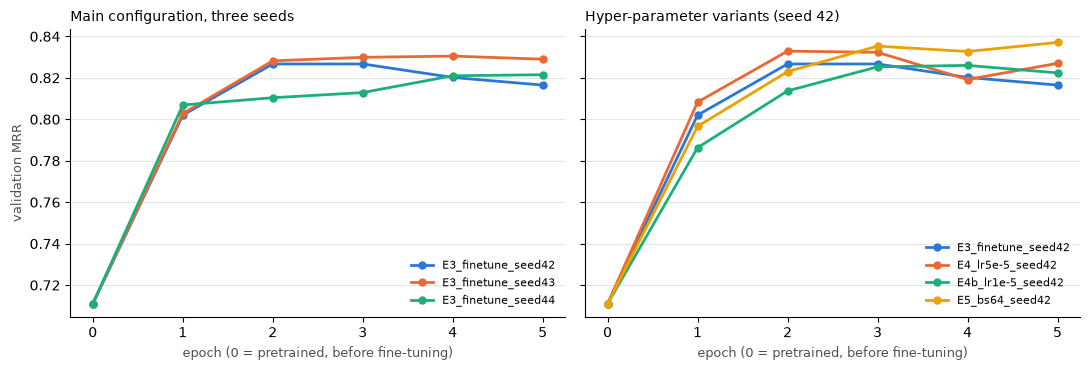

,E3_finetune_seed42,E3_finetune_seed43,E3_finetune_seed44,E4_lr5e-5_seed42,E4b_lr1e-5_seed42,E5_bs64_seed42
epoch,,,,,,
0,NaN,NaN,NaN,NaN,NaN,NaN
1,0.244,0.248,0.230,0.210,0.281,0.403
2,0.081,0.105,0.111,0.054,0.113,0.166
3,0.076,0.078,0.090,0.045,0.109,0.142
4,0.072,0.080,0.069,0.042,0.108,0.132
5,0.046,0.070,0.058,0.024,0.076,0.130


In [5]:
import matplotlib.pyplot as plt
COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]   # Colour-blind-safe colours from a validated palette.
panels = [("Main configuration, three seeds", ["E3_finetune_seed42", "E3_finetune_seed43", "E3_finetune_seed44"]),
          ("Hyper-parameter variants (seed 42)", ["E3_finetune_seed42", "E4_lr5e-5_seed42", "E4b_lr1e-5_seed42", "E5_bs64_seed42"])]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, (title, names) in zip(axes, panels):
    for color, name in zip(COLORS, names):
        ep = logs[name]["epochs"]
        ax.plot([e["epoch"] for e in ep], [e["val"]["mrr"] for e in ep], color=color, linewidth=2, marker="o", markersize=5, label=name)
    ax.set_title(title, loc="left", fontsize=10)
    ax.set_xlabel("epoch (0 = pretrained, before fine-tuning)", fontsize=9, color="#52514e")
    ax.grid(axis="y", color="#e6e5e1"); ax.set_axisbelow(True)
    for side in ["top", "right"]: ax.spines[side].set_visible(False)
    ax.legend(fontsize=8, frameon=False)
axes[0].set_ylabel("validation MRR", fontsize=9, color="#52514e")
fig.tight_layout(); fig.savefig(RESULTS_DIR / "figures" / "training_curves.png", dpi=200); plt.show()
pd.DataFrame({name: [e["train_loss"] for e in log["epochs"]] for name, log in logs.items()}).rename_axis("epoch").round(3)

Every run followed the same pattern. The validation MRR jumped from 0.711 to about 0.80 after the first epoch and then levelled off between 0.81 and 0.84. The training loss kept falling and reached values between 0.02 and 0.13 by the fifth epoch, while the validation score stopped improving. This gap shows that the model began to overfit the 711 training pairs after a few epochs, which is why we keep the best epoch on the validation set rather than the last one. The lower learning rate of 1e-5 learned more slowly, and the run with a batch size of 64 was still improving slightly at epoch 5, because larger batches give fewer updates per epoch.

## Comparing the Fine-Tuned Models

The first table places the fine-tuned runs next to the TF-IDF baseline and the pretrained model, and the second gives the mean and standard deviation of the three E3 seeds.

In [6]:
names = ["E1_tfidf", "E2_pretrained"] + [n for n, _, _ in CONFIGS]
table = experiments_table(names).drop(columns="description")
table["best_epoch"] = table.name.map(lambda n: logs[n]["best_epoch"] if n in logs else None)
display(table.round(3))
seeds = table[table.name.str.startswith("E3_")]
seeds.drop(columns=["name", "best_epoch"]).agg(["mean", "std"]).round(3)

,name,val_recall@1,val_recall@3,val_mrr,test_recall@1,test_recall@3,test_mrr,paraphrase_recall@1,paraphrase_recall@3,paraphrase_mrr,best_epoch
0,E1_tfidf,0.553,0.709,0.656,0.237,0.325,0.294,0.075,0.250,0.211,NaN
1,E2_pretrained,0.624,0.794,0.711,0.316,0.424,0.388,0.475,0.600,0.552,NaN
2,E3_finetune_seed42,0.752,0.886,0.827,0.280,0.401,0.367,0.450,0.600,0.534,2.0
3,E3_finetune_seed43,0.752,0.886,0.830,0.297,0.396,0.376,0.450,0.600,0.534,4.0
4,E3_finetune_seed44,0.745,0.894,0.822,0.294,0.398,0.377,0.450,0.600,0.535,5.0
5,E4_lr5e-5_seed42,0.766,0.886,0.833,0.277,0.370,0.355,0.450,0.625,0.538,2.0
6,E4b_lr1e-5_seed42,0.752,0.886,0.826,0.285,0.427,0.376,0.450,0.600,0.537,4.0
7,E5_bs64_seed42,0.766,0.894,0.837,0.285,0.396,0.372,0.450,0.600,0.533,5.0


,val_recall@1,val_recall@3,val_mrr,test_recall@1,test_recall@3,test_mrr,paraphrase_recall@1,paraphrase_recall@3,paraphrase_mrr
mean,0.749,0.889,0.826,0.290,0.398,0.373,0.45,0.6,0.534
std,0.004,0.004,0.005,0.009,0.003,0.006,0.00,0.0,0.000


Fine-tuning clearly helped on questions similar to the training data. The validation MRR rose from 0.711 for the pretrained model to 0.826 on average across the three seeds, and the standard deviation of 0.005 shows that this gain is far larger than the variation caused by the random seed.

The test results tell a different story. Every fine-tuned run had a lower test Recall@1, between 0.277 and 0.297, than the pretrained model's 0.316. The mean of the three seeds, 0.290, is about three standard deviations below the pretrained result, so this drop is also unlikely to be due to chance. The training and validation questions are crowdsourced questions from Nigeria, while the test questions are expert exam prompts mostly from Kenya and Malawi, and fine-tuning appears to specialise the model to the first style.

The other experiments support this explanation. The learning rate of 5e-5 gave the best validation score among the E3 and E4 runs but the worst test score, which suggests that faster adaptation leads to stronger specialisation. The gentler learning rate of 1e-5 behaved almost exactly like 2e-5 on the test set, with a test MRR of 0.376 against the E3 mean of 0.373, so slower updates did not recover the pretrained model's test performance. The batch size of 64 reached the highest validation MRR (0.837) with a test score close to E3, although its advantage of 0.011 over the E3 mean is only about two seed standard deviations and comes from a single run. On the paraphrased questions, every fine-tuned model answered 18 of the 40 correctly, one fewer than the pretrained model.

## Why Test Accuracy Did Not Follow Validation

One possible explanation for the drop is that fine-tuning makes the model prefer the answers it saw during training. If this is the case, the top answer for a test question should more often be a training answer, which is always wrong for a test question. The next cell checks this for every model.

In [7]:
split_of = dict(zip(kb.answer, kb.split))
rows = []
for name in ["E2_pretrained"] + [n for n, _, _ in CONFIGS]:
    p = pd.read_csv(RESULTS_DIR / "experiments" / name / "predictions_test.csv")
    from_train = p.top1_answer.map(split_of).eq("train")
    rows.append({"model": name, "test R@1": round(p.correct_at_1.mean(), 3),
                 "top-1 answer is a training answer": round(from_train.mean(), 3),
                 "…among wrong answers": round(from_train[~p.correct_at_1].mean(), 3)})
pd.DataFrame(rows)

,model,test R@1,top-1 answer is a training answer,…among wrong answers
0,E2_pretrained,0.316,0.130,0.190
1,E3_finetune_seed42,0.280,0.181,0.251
2,E3_finetune_seed43,0.297,0.144,0.205
3,E3_finetune_seed44,0.294,0.155,0.220
4,E4_lr5e-5_seed42,0.277,0.226,0.312
5,E4b_lr1e-5_seed42,0.285,0.153,0.213
6,E5_bs64_seed42,0.285,0.161,0.225


The results support this explanation. The pretrained model returned a training answer as its top result for 13.0% of the test questions, while the fine-tuned models did so for between 14.4% and 22.6%. The run with the highest learning rate showed the strongest effect, with training answers making up 31.2% of its wrong answers. The fine-tuned models therefore learned to favour the answers they were trained on, and a large part of their additional test errors are these training answers. This is a form of overfitting to the training distribution rather than a bug, and it explains why better validation scores did not carry over to the test set.

## Choosing the Final Model

The final model is the fine-tuned run with the highest validation MRR. This rule was fixed before the test results were examined, and the test set is not used for the choice.

In [8]:
finetuned = table[table.name.isin(logs)].sort_values("val_mrr", ascending=False)
final_name = finetuned.iloc[0]["name"]
choice = {"final_model": f"models/{final_name}", "selected_by": "highest validation MRR among fine-tuned runs",
          "val_mrr": float(finetuned.iloc[0]["val_mrr"]), "test_mrr": float(finetuned.iloc[0]["test_mrr"])}
json.dump(choice, open(RESULTS_DIR / "final_model_choice.json", "w"), indent=2)
choice

{'final_model': 'models/E5_bs64_seed42',
 'selected_by': 'highest validation MRR among fine-tuned runs',
 'val_mrr': 0.8371,
 'test_mrr': 0.3719}

The rule selects E5, the run with a batch size of 64, which reached a validation MRR of 0.837. On the expert test set, the pretrained model is still slightly better, with a test MRR of 0.388 compared with 0.372, and this has to be reported honestly. The validation set contains no expert questions, so it could not reveal this difference, and the only real fix would be a validation set that includes expert questions, which is not possible here without using the official test set. The next notebook uses the final model to build the confidence check that decides when the assistant should answer and when it should refuse.